Kod i algorytm do wycinania:

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#liczy najdluzsze linie prawie biale z gory i zdolu
def longest_runs_from_top(mask: np.ndarray) -> np.ndarray:
    h, w = mask.shape
    runs = np.zeros(w, dtype=np.int32)
    for x in range(w):
        col = mask[:, x]
        idx = np.where(~col)[0]
        runs[x] = (idx[0] if idx.size else h)
    return runs


def longest_runs_from_bottom(mask: np.ndarray) -> np.ndarray:
    h, w = mask.shape
    runs = np.zeros(w, dtype=np.int32)
    for x in range(w):
        col = mask[::-1, x]
        idx = np.where(~col)[0]
        runs[x] = (idx[0] if idx.size else h)
    return runs


#zmienic mozna i dotiunowac
def crop_by_axis_runs(
    img,
    pre_cut_frac=0.0125,
    post_cut_frac=0.0125,

    #4*0.0125= 0.05 wiec ZAWSZE usunie chociaz 5% obrazu troche sanity check by nie bylo bialych smog

    #tbh zgadywalem liczby
    zone_frac=0.25, #ile analizujemy z gory i dolu zwroci przynajnmniej 50% orginalnego orbazu
    white_thresh=245, #czym jest prawie bialy
    run_len_thresh=50, #jak dlugi musi byc bialy 
    min_cols_frac=0.05, # dziury w lini
    use_percentile=99.5
):
    if img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img

    H, W = gray.shape
    #precut
    pre = int(round(pre_cut_frac * H))
    work_top = pre
    work_bottom = H - pre
    if work_bottom <= work_top + 30:
        return 0, H

    work = gray[work_top:work_bottom, :]
    h, w = work.shape

    zone_h = max(1, int(round(zone_frac * h)))

    #top i bottom zone maska
    top_zone = work[:zone_h, :]
    bot_zone = work[h - zone_h:, :]

    top_mask = (top_zone >= white_thresh)
    bot_mask = (bot_zone >= white_thresh)

    #najdluzsza w prawie biala kreska na dole i gorze
    top_runs = longest_runs_from_top(top_mask)
    bot_runs = longest_runs_from_bottom(bot_mask)

    min_cols = max(1, int(round(min_cols_frac * w)))


    #ile kolumn ma run
    top_good = np.count_nonzero(top_runs >= run_len_thresh)
    cut_top = int(np.percentile(top_runs, use_percentile)) if top_good >= min_cols else 0

    bot_good = np.count_nonzero(bot_runs >= run_len_thresh)
    cut_bot = int(np.percentile(bot_runs, use_percentile)) if bot_good >= min_cols else 0

    top = work_top + cut_top
    bottom = work_bottom - cut_bot

    top = int(np.clip(top, 0, H))
    bottom = int(np.clip(bottom, 0, H))
    if bottom <= top + 30:
        top, bottom = work_top, work_bottom

    #post cut
    out_h = bottom - top
    post = int(round(post_cut_frac * out_h))
    top2 = int(np.clip(top + post, 0, H))
    bottom2 = int(np.clip(bottom - post, 0, H))
    if bottom2 <= top2 + 30:
        top2, bottom2 = top, bottom

    return top2, bottom2


def show_crop(
    img_path: str,
    *,
    pre_cut_frac=0.0125,
    post_cut_frac=0.0125,
    zone_frac=0.25,
    white_thresh=245,
    run_len_thresh=50,
    min_cols_frac=0.05,
    use_percentile=99.5,
    figsize=(10, 6)
):
    img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Nie mogę wczytać: {img_path}")

    top, bottom = crop_by_axis_runs(
        img,
        pre_cut_frac=pre_cut_frac,
        post_cut_frac=post_cut_frac,
        zone_frac=zone_frac,
        white_thresh=white_thresh,
        run_len_thresh=run_len_thresh,
        min_cols_frac=min_cols_frac,
        use_percentile=use_percentile,
    )

    # do podglądu w RGB
    if img.ndim == 2:
        disp = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    else:
        disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    H, W = disp.shape[:2]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(disp)
    ax.add_patch(Rectangle((0, top), W, bottom - top, fill=False, linewidth=2.5, edgecolor="lime"))
    ax.set_title(f"{img_path}\nZachowany obszar: top={top}, bottom={bottom} (H={H})")
    ax.axis("off")
    plt.show()

    cropped = img[top:bottom, :]

    if cropped.ndim == 2:
        cropped_disp = cv2.cvtColor(cropped, cv2.COLOR_GRAY2RGB)
    else:
        cropped_disp = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(cropped_disp)
    ax.set_title("Po przycięciu (wynik)")
    ax.axis("off")
    plt.show()

    return cropped, (top, bottom)


Kolejne zdj dla sprawdzenia

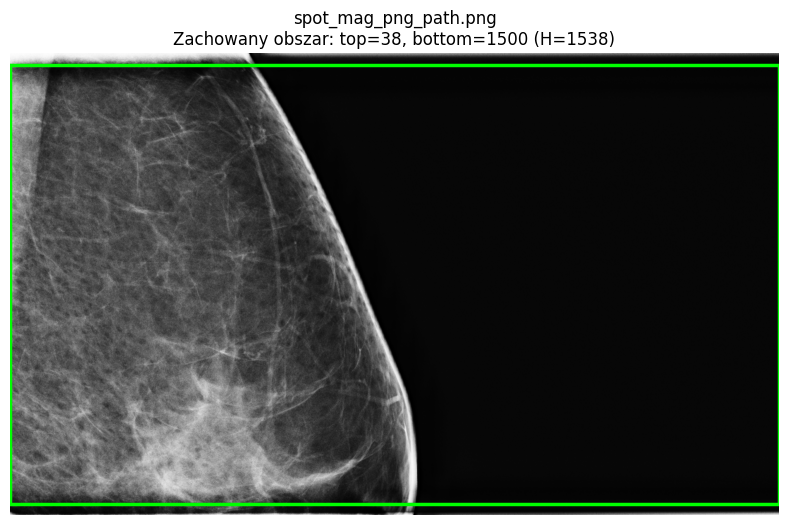

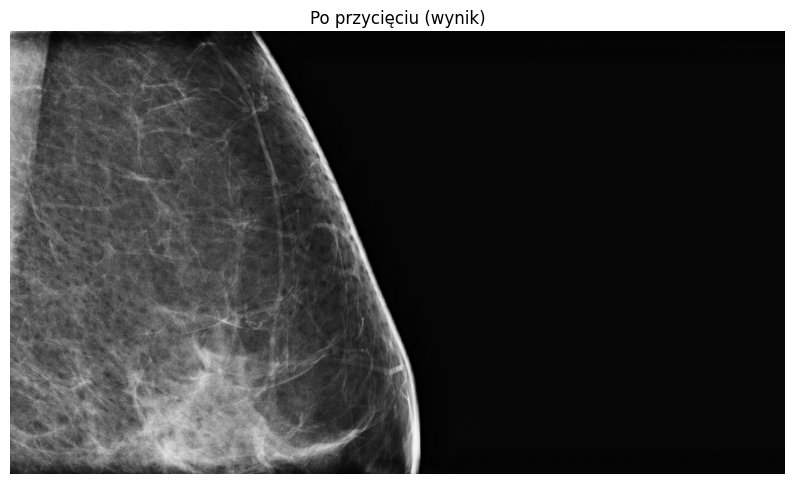

(array([[186, 193, 201, ...,   3,   3,   3],
        [202, 193, 202, ...,   3,   3,   3],
        [212, 186, 197, ...,   3,   3,   4],
        ...,
        [ 21,  36,  20, ...,   6,   7,   6],
        [ 30,  24,  27, ...,   6,   6,   6],
        [ 30,  28,  22, ...,   6,   7,   6]],
       shape=(1462, 2560), dtype=uint8),
 (38, 1500))

In [2]:
show_crop(r"spot_mag_png_path.png")

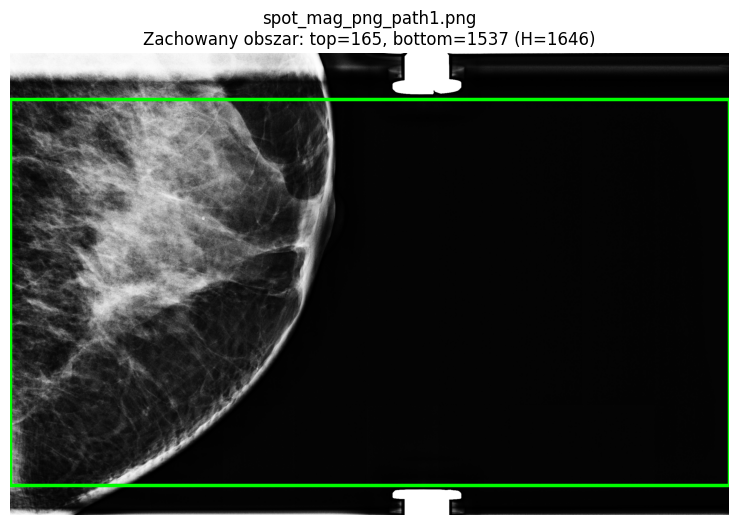

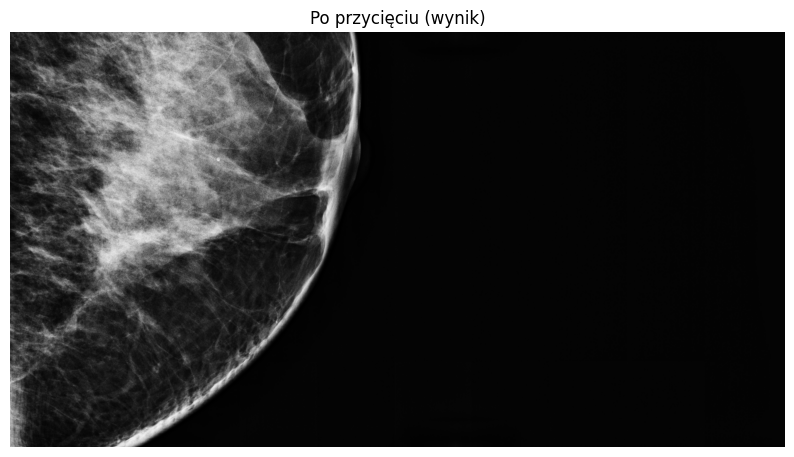

(array([[ 32,  37,  39, ...,   3,   3,   3],
        [ 24,  25,  27, ...,   3,   3,   3],
        [ 25,  25,  15, ...,   3,   3,   3],
        ...,
        [160, 166, 173, ...,   4,   4,   4],
        [171, 169, 166, ...,   4,   4,   4],
        [184, 168, 177, ...,   4,   4,   4]],
       shape=(1372, 2560), dtype=uint8),
 (165, 1537))

In [3]:
show_crop(r"spot_mag_png_path1.png")

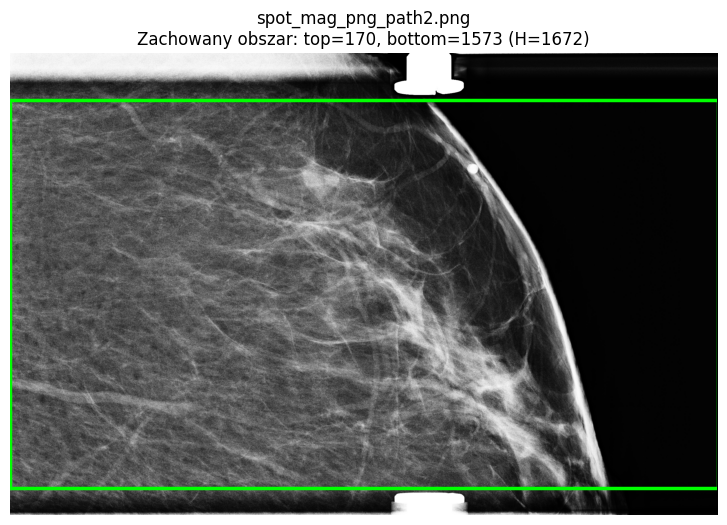

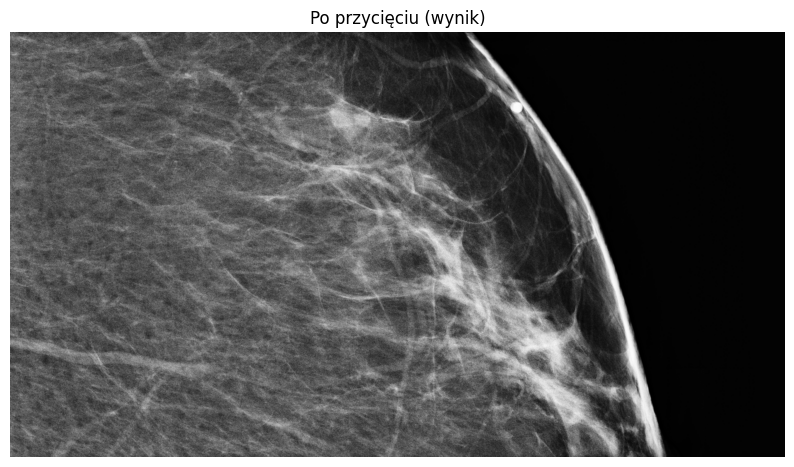

(array([[ 77,  80,  81, ...,   3,   3,   3],
        [101,  99, 104, ...,   3,   3,   3],
        [ 95,  89, 112, ...,   3,   3,   3],
        ...,
        [111, 109, 112, ...,   2,   3,   3],
        [100,  89,  81, ...,   3,   3,   3],
        [ 87, 120,  99, ...,   3,   3,   3]],
       shape=(1403, 2560), dtype=uint8),
 (170, 1573))

In [4]:
show_crop(r"spot_mag_png_path2.png")

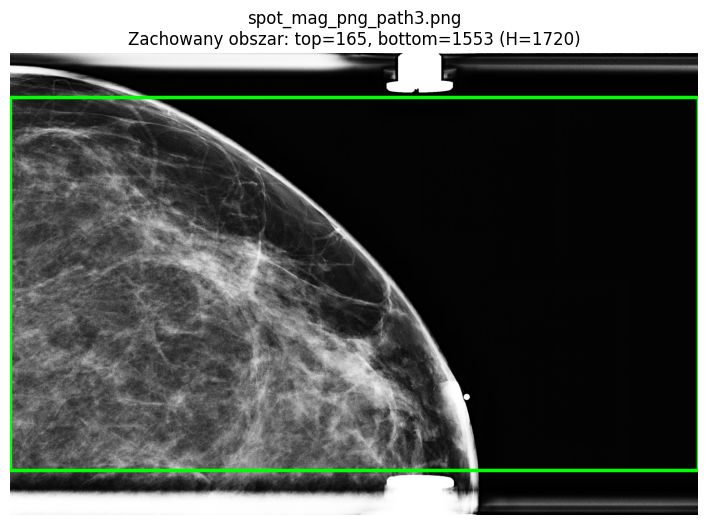

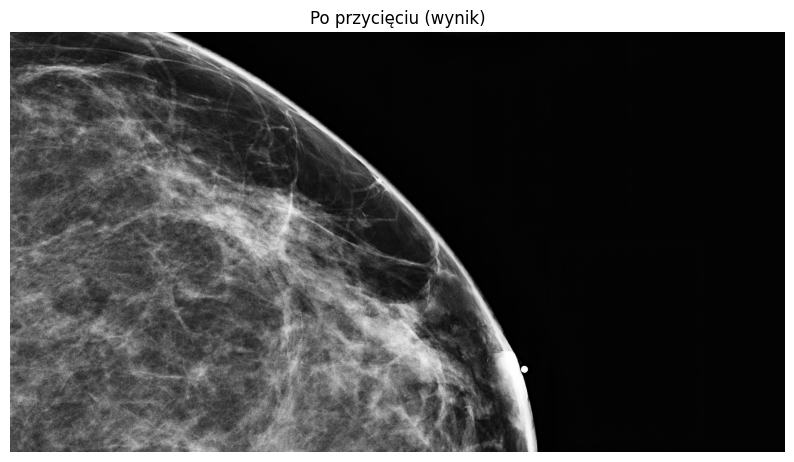

(array([[31, 35, 36, ...,  3,  2,  2],
        [33, 30, 41, ...,  2,  2,  2],
        [25, 32, 30, ...,  2,  3,  3],
        ...,
        [64, 94, 83, ...,  2,  2,  2],
        [62, 78, 87, ...,  2,  2,  2],
        [62, 69, 87, ...,  2,  2,  2]], shape=(1388, 2560), dtype=uint8),
 (165, 1553))

In [5]:
show_crop(r"spot_mag_png_path3.png")

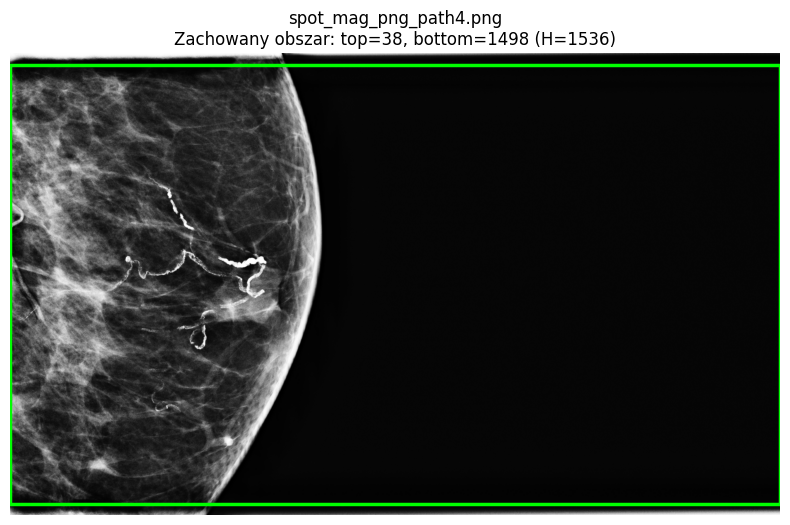

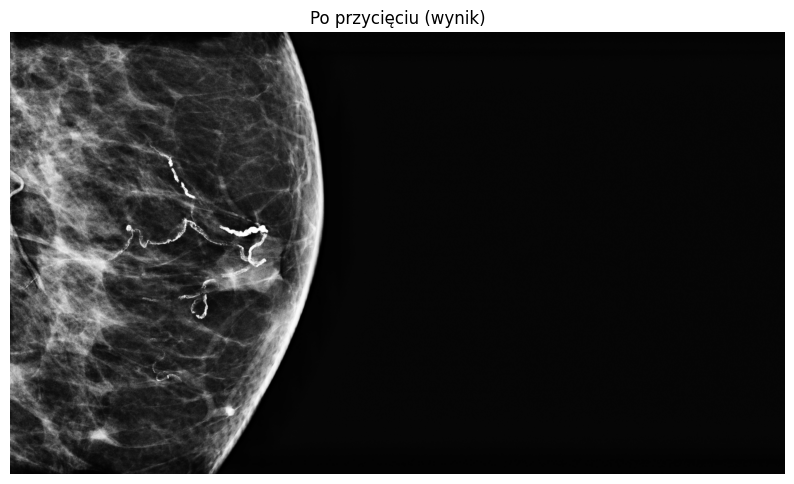

(array([[12, 15, 10, ...,  4,  4,  4],
        [15, 18, 17, ...,  4,  3,  3],
        [17, 17, 14, ...,  3,  3,  3],
        ...,
        [ 8,  7,  8, ...,  3,  3,  3],
        [ 8,  7,  6, ...,  3,  3,  3],
        [ 5,  6,  7, ...,  3,  3,  4]], shape=(1460, 2560), dtype=uint8),
 (38, 1498))

In [6]:
show_crop(r"spot_mag_png_path4.png")

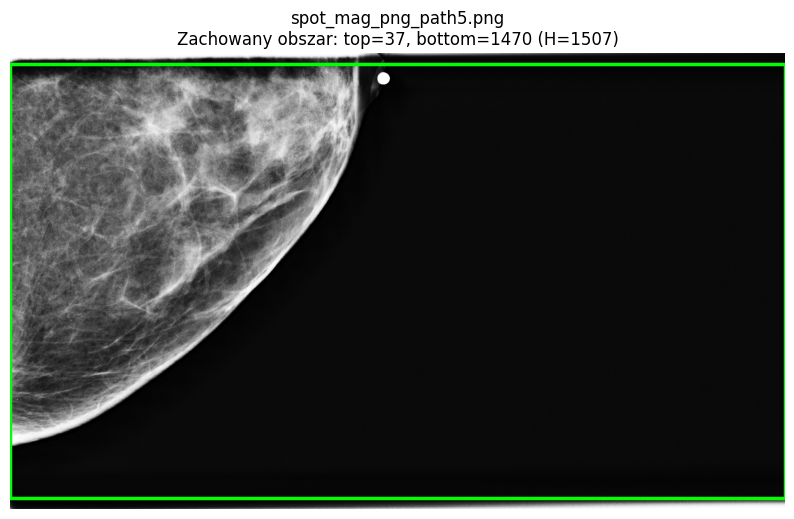

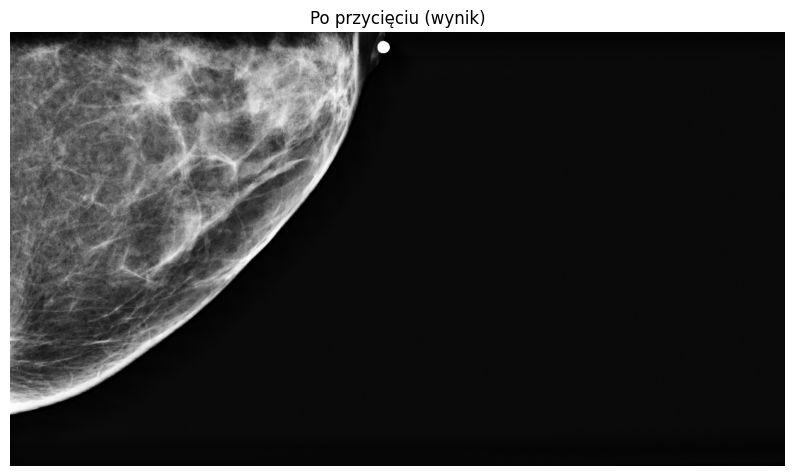

(array([[54, 49, 47, ...,  6,  5,  6],
        [62, 32, 29, ...,  6,  5,  5],
        [25, 20, 20, ...,  5,  5,  6],
        ...,
        [ 5,  6,  5, ...,  5,  5,  4],
        [ 5,  5,  5, ...,  5,  6,  5],
        [ 5,  5,  4, ...,  6,  7,  8]], shape=(1433, 2560), dtype=uint8),
 (37, 1470))

In [7]:
show_crop(r"spot_mag_png_path5.png")

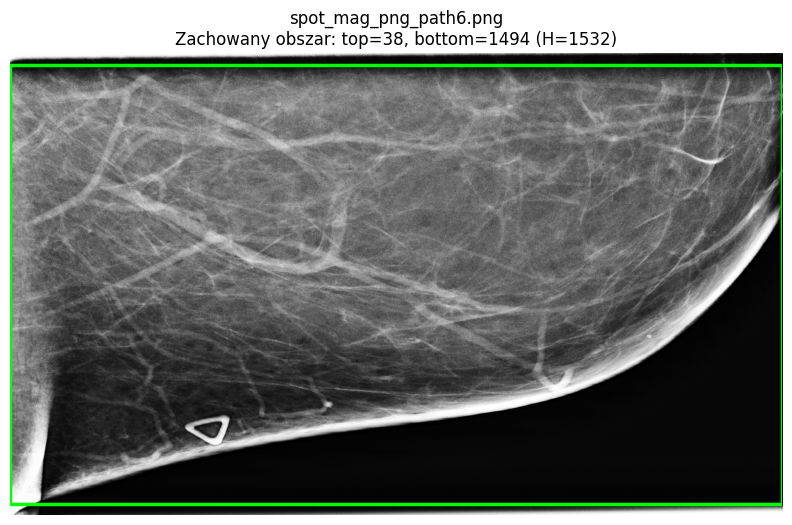

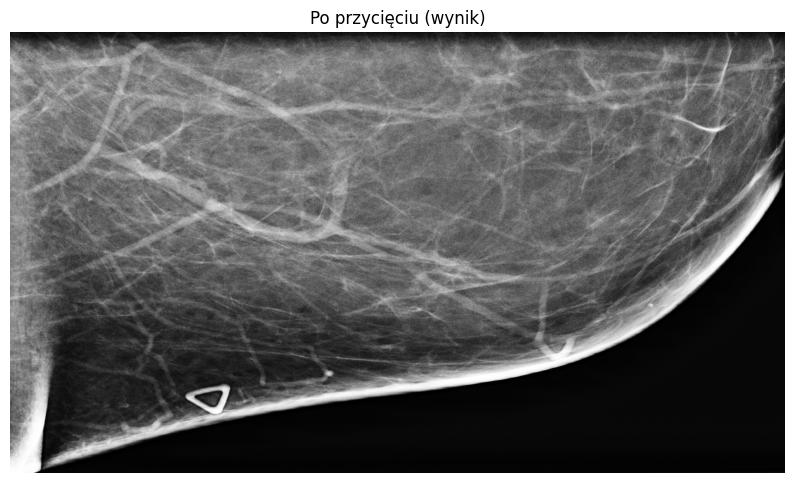

(array([[ 19,  13,  12, ...,   6,  10,   4],
        [ 17,  26,  24, ...,   5,   9,   7],
        [ 15,  14,  19, ...,   5,   6,   7],
        ...,
        [254, 255, 255, ...,  10,  11,  14],
        [255, 255, 255, ...,  14,  13,  12],
        [255, 255, 255, ...,  15,  15,  16]],
       shape=(1456, 2560), dtype=uint8),
 (38, 1494))

In [8]:
show_crop(r"spot_mag_png_path6.png")

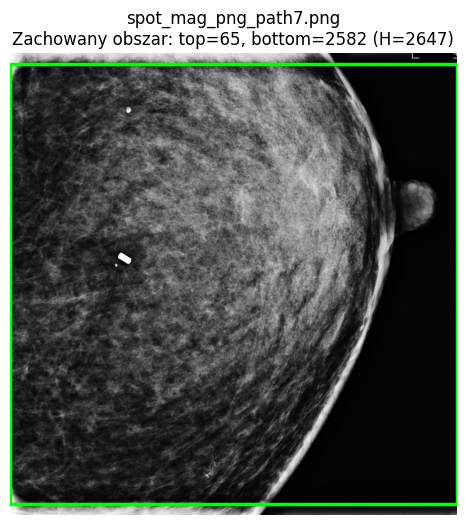

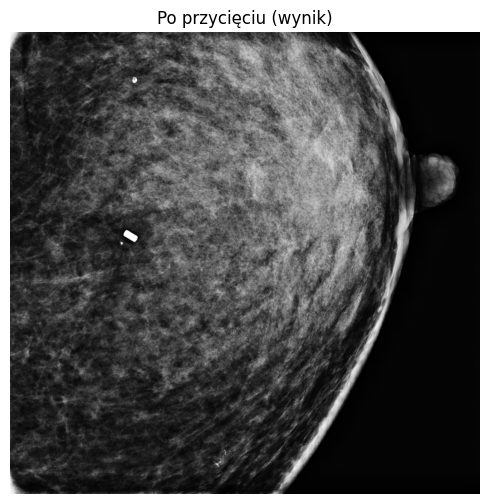

(array([[252, 252, 252, ...,   2,   2,   1],
        [251, 252, 253, ...,   2,   2,   1],
        [253, 252, 253, ...,   2,   2,   1],
        ...,
        [252, 250, 250, ...,   4,   4,   6],
        [251, 250, 251, ...,   4,   4,   7],
        [251, 250, 249, ...,   4,   5,   6]],
       shape=(2517, 2560), dtype=uint8),
 (65, 2582))

In [9]:
show_crop(r"spot_mag_png_path7.png")